In [1]:
import pandas as pd

df = pd.read_csv("final_dataset (1).csv")

In [2]:
df = pd.read_csv("df_anonymized (2).csv")

Training Model 1 (Ookla QoS)...
Epoch 1/23 - Loss: 0.6644
Epoch 2/23 - Loss: 0.5834
Epoch 3/23 - Loss: 0.5678
Epoch 4/23 - Loss: 0.5623
Epoch 5/23 - Loss: 0.5596
Epoch 6/23 - Loss: 0.5576
Epoch 7/23 - Loss: 0.5556
Epoch 8/23 - Loss: 0.5549
Epoch 9/23 - Loss: 0.5539
Epoch 10/23 - Loss: 0.5538
Epoch 11/23 - Loss: 0.5527
Epoch 12/23 - Loss: 0.5524
Epoch 13/23 - Loss: 0.5516
Epoch 14/23 - Loss: 0.5516
Epoch 15/23 - Loss: 0.5511
Epoch 16/23 - Loss: 0.5506
Epoch 17/23 - Loss: 0.5504
Epoch 18/23 - Loss: 0.5508
Epoch 19/23 - Loss: 0.5501
Epoch 20/23 - Loss: 0.5492
Epoch 21/23 - Loss: 0.5497
Epoch 22/23 - Loss: 0.5495
Epoch 23/23 - Loss: 0.5490


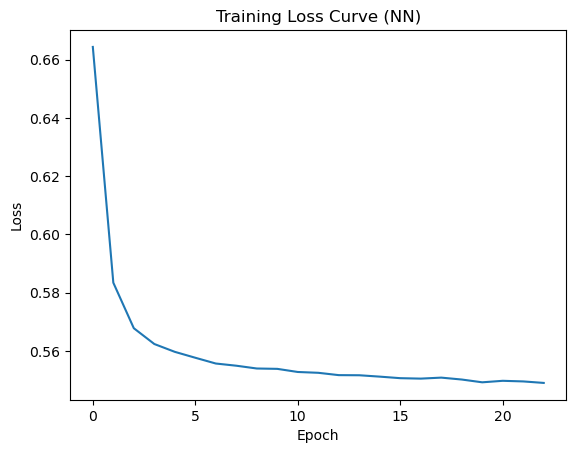

Model 1 saved.

Training Model 2 (Signal Strength)...
Model 2 saved.


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
import joblib
import os
import matplotlib.pyplot as plt

# --- LOGIC ---
def classify_network(download, latency):
    if download >= 25 and latency <= 40:
        return 2
    elif download >= 5 and latency <= 100:
        return 1
    else:
        return 0

# --- MODEL ---
class OoklaNN(nn.Module):
    def __init__(self, input_size):
        super(OoklaNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )

    def forward(self, x):
        return self.network(x)

def train_ookla_model():
    print("Training Model 1 (Ookla QoS)...")
    df = pd.read_csv("final_dataset (1).csv")

    df = df[df['avg_d_kbps'] > 0]
    df = df[df['avg_lat_ms'] > 0]

    df['download_mbps'] = df['avg_d_kbps'] / 1000
    df['upload_mbps'] = df['avg_u_kbps'] / 1000
    df['latency_ms'] = df['avg_lat_ms']

    df['target'] = df.apply(lambda row: classify_network(
        row['download_mbps'], row['latency_ms']), axis=1)

    # -------- FEATURE ENGINEERING --------
    df['upload_latency_ratio'] = df['upload_mbps'] / (df['latency_ms'] + 1)

    df['latency_bucket'] = pd.cut(
        df['latency_ms'],
        bins=[0, 50, 100, float('inf')],
        labels=[0, 1, 2]
    )
    df['latency_bucket'] = df['latency_bucket'].cat.codes

    df['geo_interaction'] = df['lat'] * df['lon']

    # -------- FINAL FEATURES --------
    features = [
        'upload_mbps',
        'lat',
        'lon',
        'upload_latency_ratio',
        'latency_bucket',
        'geo_interaction'
    ]

    X = df[features]
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    class_weights = compute_class_weight(
        'balanced', classes=np.unique(y_train), y=y_train
    )
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

    train_ds = TensorDataset(
        torch.tensor(X_train_scaled, dtype=torch.float32),
        torch.tensor(y_train.values, dtype=torch.long)
    )

    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

    model = OoklaNN(input_size=len(features))
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    losses = []

    for epoch in range(23):
        total_loss = 0
        model.train()

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)

        print(f"Epoch {epoch+1}/23 - Loss: {avg_loss:.4f}")

    # --- GRAPH ---
    plt.plot(losses)
    plt.title("Training Loss Curve (NN)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    torch.save(model.state_dict(), 'ookla_nn.pth')
    joblib.dump(scaler, 'ookla_scaler.pkl')
    print("Model 1 saved.")

def train_signal_model():
    print("\nTraining Model 2 (Signal Strength)...")
    
    df = pd.read_csv("df_anonymized (2).csv")

    df['download_mbps'] = df['Downstream Bandwidth'] / 1000
    
    def classify_signal(rsrp, rsrq):
        if rsrp > -85 and rsrq > -12: return 2
        if rsrp > -105 and rsrq > -16: return 1
        return 0

    df['target'] = df.apply(lambda row: classify_signal(
        row['RSRP LTE'], row['RSRQ LTE']), axis=1)

    features = ['RSRP LTE', 'RSRQ LTE', 'SNR LTE', 'CQI LTE', 'dBm']
    df = df.dropna(subset=features)

    X = df[features]
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    joblib.dump(model, 'signal_xgb.pkl')
    print("Model 2 saved.")

if __name__ == "__main__":
    train_ookla_model()
    train_signal_model()

In [5]:
import pandas as pd
import torch
import joblib
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# -------- MODEL (same as training) --------
class OoklaNN(torch.nn.Module):
    def __init__(self, input_size):
        super(OoklaNN, self).__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(input_size, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.15),
            torch.nn.Linear(64, 32),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.1),
            torch.nn.Linear(32, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 3)
        )

    def forward(self, x):
        return self.network(x)

# -------- LOAD DATA --------
df = pd.read_csv("final_dataset (1).csv")

df = df[df['avg_d_kbps'] > 0]
df = df[df['avg_lat_ms'] > 0]

df['download_mbps'] = df['avg_d_kbps'] / 1000
df['upload_mbps'] = df['avg_u_kbps'] / 1000
df['latency_ms'] = df['avg_lat_ms']

# SAME TARGET
def classify_network(download, latency):
    if download >= 25 and latency <= 40:
        return 2
    elif download >= 5 and latency <= 100:
        return 1
    else:
        return 0

df['target'] = df.apply(lambda row: classify_network(
    row['download_mbps'], row['latency_ms']), axis=1)

# -------- SAME FEATURES --------
df['upload_latency_ratio'] = df['upload_mbps'] / (df['latency_ms'] + 1)

df['latency_bucket'] = pd.cut(
    df['latency_ms'],
    bins=[0, 50, 100, float('inf')],
    labels=[0, 1, 2]
)
df['latency_bucket'] = df['latency_bucket'].cat.codes

df['geo_interaction'] = df['lat'] * df['lon']

features = [
    'upload_mbps',
    'lat',
    'lon',
    'upload_latency_ratio',
    'latency_bucket',
    'geo_interaction'
]

X = df[features]
y = df['target']

# -------- SPLIT --------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------- LOAD SCALER --------
scaler = joblib.load("ookla_scaler.pkl")
X_test_scaled = scaler.transform(X_test)

# -------- LOAD MODEL --------
model = OoklaNN(input_size=6)
model.load_state_dict(torch.load("ookla_nn.pth"))
model.eval()

# -------- PREDICT --------
with torch.no_grad():
    y_pred = model(torch.tensor(X_test_scaled, dtype=torch.float32))
    _, pred = torch.max(y_pred, 1)

# -------- RESULT --------
print("Test Accuracy:", accuracy_score(y_test, pred.numpy()))

Test Accuracy: 0.7765320972349485


In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# -------- LOGIC --------
def classify_network(download, latency):
    if download >= 25 and latency <= 40:
        return 2
    elif download >= 5 and latency <= 100:
        return 1
    else:
        return 0

# -------- MODEL --------
class OoklaNN(nn.Module):
    def __init__(self, input_size):
        super(OoklaNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )

    def forward(self, x):
        return self.network(x)

# ===========================
# MAIN
# ===========================
def train_and_evaluate():
    print("Training Model...")

    df = pd.read_csv("final_dataset (1).csv")

    # CLEANING
    df = df[df['avg_d_kbps'] > 0]
    df = df[df['avg_lat_ms'] > 0]

    # BASIC FEATURES
    df['download_mbps'] = df['avg_d_kbps'] / 1000
    df['upload_mbps'] = df['avg_u_kbps'] / 1000
    df['latency_ms'] = df['avg_lat_ms']

    # TARGET
    df['target'] = df.apply(lambda row: classify_network(
        row['download_mbps'], row['latency_ms']), axis=1)

    # FEATURE ENGINEERING
    df['upload_latency_ratio'] = df['upload_mbps'] / (df['latency_ms'] + 1)

    df['latency_bucket'] = pd.cut(
        df['latency_ms'],
        bins=[0, 50, 100, float('inf')],
        labels=[0, 1, 2]
    ).cat.codes

    df['geo_interaction'] = df['lat'] * df['lon']

    # FINAL FEATURES
    features = [
        'upload_mbps',
        'lat',
        'lon',
        'upload_latency_ratio',
        'latency_bucket',
        'geo_interaction'
    ]

    X = df[features]
    y = df['target']

    # SPLIT
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # SCALING
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # CLASS WEIGHTS (IMPORTANT)
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    weights = torch.tensor(class_weights, dtype=torch.float32)

    # MODEL
    model = OoklaNN(input_size=len(features))
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    # DATA LOADER (IMPORTANT FIX)
    train_ds = TensorDataset(
        torch.tensor(X_train_scaled, dtype=torch.float32),
        torch.tensor(y_train.values, dtype=torch.long)
    )

    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

    # TRAINING LOOP
    for epoch in range(23):
        model.train()
        total_loss = 0

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()

            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/23 - Loss: {avg_loss:.4f}")

    # ===========================
    # EVALUATION
    # ===========================
    model.eval()

    # TRAIN ACCURACY
    with torch.no_grad():
        train_out = model(torch.tensor(X_train_scaled, dtype=torch.float32))
        _, train_pred = torch.max(train_out, 1)

    train_acc = accuracy_score(y_train, train_pred.numpy())

    # TEST ACCURACY
    with torch.no_grad():
        test_out = model(torch.tensor(X_test_scaled, dtype=torch.float32))
        _, test_pred = torch.max(test_out, 1)

    test_acc = accuracy_score(y_test, test_pred.numpy())

    print("\n✅ FINAL RESULTS")
    print("Training Accuracy :", train_acc)
    print("Testing Accuracy  :", test_acc)


# ===========================
# RUN
# ===========================
if __name__ == "__main__":
    train_and_evaluate()

Training Model...
Epoch 1/23 - Loss: 0.6719
Epoch 2/23 - Loss: 0.5885
Epoch 3/23 - Loss: 0.5700
Epoch 4/23 - Loss: 0.5636
Epoch 5/23 - Loss: 0.5599
Epoch 6/23 - Loss: 0.5575
Epoch 7/23 - Loss: 0.5560
Epoch 8/23 - Loss: 0.5550
Epoch 9/23 - Loss: 0.5539
Epoch 10/23 - Loss: 0.5529
Epoch 11/23 - Loss: 0.5527
Epoch 12/23 - Loss: 0.5517
Epoch 13/23 - Loss: 0.5518
Epoch 14/23 - Loss: 0.5511
Epoch 15/23 - Loss: 0.5507
Epoch 16/23 - Loss: 0.5507
Epoch 17/23 - Loss: 0.5502
Epoch 18/23 - Loss: 0.5494
Epoch 19/23 - Loss: 0.5499
Epoch 20/23 - Loss: 0.5492
Epoch 21/23 - Loss: 0.5494
Epoch 22/23 - Loss: 0.5491
Epoch 23/23 - Loss: 0.5487

✅ FINAL RESULTS
Training Accuracy : 0.7855763270659468
Testing Accuracy  : 0.7826946226126952


Training Model 1 (Ookla QoS)...


Epoch 1/23 - Loss: 0.5779
Epoch 2/23 - Loss: 0.4527
Epoch 3/23 - Loss: 0.4274
Epoch 4/23 - Loss: 0.4113
Epoch 5/23 - Loss: 0.3951
Epoch 6/23 - Loss: 0.3860
Epoch 7/23 - Loss: 0.3823
Epoch 8/23 - Loss: 0.3803
Epoch 9/23 - Loss: 0.3787
Epoch 10/23 - Loss: 0.3765
Epoch 11/23 - Loss: 0.3755
Epoch 12/23 - Loss: 0.3741
Epoch 13/23 - Loss: 0.3744
Epoch 14/23 - Loss: 0.3736
Epoch 15/23 - Loss: 0.3727
Epoch 16/23 - Loss: 0.3729
Epoch 17/23 - Loss: 0.3716
Epoch 18/23 - Loss: 0.3706
Epoch 19/23 - Loss: 0.3702
Epoch 20/23 - Loss: 0.3701
Epoch 21/23 - Loss: 0.3696
Epoch 22/23 - Loss: 0.3694
Epoch 23/23 - Loss: 0.3687


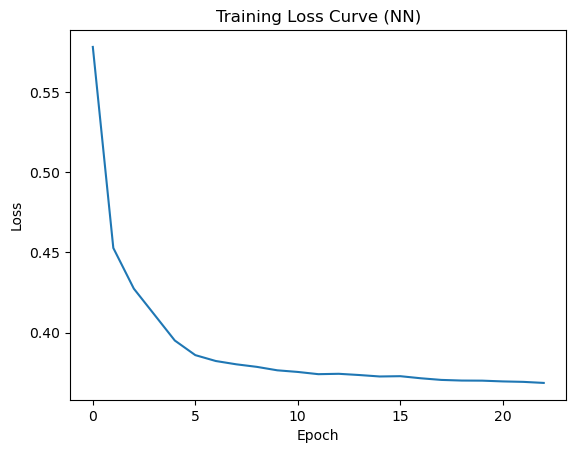

Model 1 saved.

Training Model 2 (Signal Strength)...
Model 2 saved.


In [7]:
# Final code
import pandas as pd 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
import joblib
import os
import matplotlib.pyplot as plt

def classify_network(download, upload, latency):

    # GOOD
    if latency <= 60 and download >= 12 and upload >= 3:
        return 2

    # MODERATE
    elif latency <= 110 and download >= 3 and upload >= 0.8:
        return 1

    # POOR
    else:
        return 0

# -------- MODEL --------
class OoklaNN(nn.Module):
    def __init__(self, input_size):
        super(OoklaNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )

    def forward(self, x):
        return self.network(x)

# ===========================
# MODEL 1
# ===========================
def train_ookla_model():
    print("Training Model 1 (Ookla QoS)...")

    df = pd.read_csv("final_dataset (1).csv")

    df = df[df['avg_d_kbps'] > 0]
    df = df[df['avg_lat_ms'] > 0]

    df['download_mbps'] = df['avg_d_kbps'] / 1000
    df['upload_mbps'] = df['avg_u_kbps'] / 1000
    df['latency_ms'] = df['avg_lat_ms']

    # ✅ FIXED LINE
    df['target'] = df.apply(lambda row: classify_network(
        row['download_mbps'],
        row['upload_mbps'],
        row['latency_ms']), axis=1)

    # -------- FEATURES --------
    df['upload_latency_ratio'] = df['upload_mbps'] / (df['latency_ms'] + 1)

    df['latency_bucket'] = pd.cut(
        df['latency_ms'],
        bins=[0, 50, 100, float('inf')],
        labels=[0, 1, 2]
    ).cat.codes

    df['geo_interaction'] = df['lat'] * df['lon']

    features = [
        'upload_mbps',
        'lat',
        'lon',
        'upload_latency_ratio',
        'latency_bucket',
        'geo_interaction'
    ]

    X = df[features]
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    class_weights = compute_class_weight(
        'balanced', classes=np.unique(y_train), y=y_train
    )
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

    train_ds = TensorDataset(
        torch.tensor(X_train_scaled, dtype=torch.float32),
        torch.tensor(y_train.values, dtype=torch.long)
    )

    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

    model = OoklaNN(input_size=len(features))
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    losses = []

    for epoch in range(23):
        total_loss = 0
        model.train()

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)

        print(f"Epoch {epoch+1}/23 - Loss: {avg_loss:.4f}")

    plt.plot(losses)
    plt.title("Training Loss Curve (NN)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    torch.save(model.state_dict(), 'ookla_nn.pth')
    joblib.dump(scaler, 'ookla_scaler.pkl')
    print("Model 1 saved.")

# ===========================
# MODEL 2
# ===========================
def train_signal_model():
    print("\nTraining Model 2 (Signal Strength)...")

    df = pd.read_csv("df_anonymized (2).csv")

    def classify_signal(rsrp, rsrq):
        if rsrp > -85 and rsrq > -12: return 2
        if rsrp > -105 and rsrq > -16: return 1
        return 0

    df['target'] = df.apply(lambda row: classify_signal(
        row['RSRP LTE'], row['RSRQ LTE']), axis=1)

    features = ['RSRP LTE', 'RSRQ LTE', 'SNR LTE', 'CQI LTE', 'dBm']
    df = df.dropna(subset=features)

    X = df[features]
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    joblib.dump(model, 'signal_xgb.pkl')
    print("Model 2 saved.")

# ===========================
# RUN
# ===========================
if __name__ == "__main__":
    train_ookla_model()
    train_signal_model()

In [9]:
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

# -------- NN MODEL --------
class OoklaNN(nn.Module):
    def __init__(self, input_size):
        super(OoklaNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )

    def forward(self, x):
        return self.network(x)

# -------- LOGIC (DATASET 1) --------
def classify_network(download, upload, latency):
    if latency <= 60 and download >= 12 and upload >= 3:
        return 2
    elif latency <= 110 and download >= 3 and upload >= 0.8:
        return 1
    else:
        return 0


# ===========================
# DATASET 1 → NN
# ===========================
def test_dataset1():
    print("\n📊 DATASET 1 (Neural Network)")

    df = pd.read_csv("final_dataset (1).csv")

    df = df[df['avg_d_kbps'] > 0]
    df = df[df['avg_lat_ms'] > 0]

    df['download_mbps'] = df['avg_d_kbps'] / 1000
    df['upload_mbps'] = df['avg_u_kbps'] / 1000
    df['latency_ms'] = df['avg_lat_ms']

    df['target'] = df.apply(lambda row: classify_network(
        row['download_mbps'],
        row['upload_mbps'],
        row['latency_ms']), axis=1)

    df['upload_latency_ratio'] = df['upload_mbps'] / (df['latency_ms'] + 1)

    df['latency_bucket'] = pd.cut(
        df['latency_ms'],
        bins=[0, 50, 100, float('inf')],
        labels=[0, 1, 2]
    ).cat.codes

    df['geo_interaction'] = df['lat'] * df['lon']

    features = [
        'upload_mbps', 'lat', 'lon',
        'upload_latency_ratio',
        'latency_bucket', 'geo_interaction'
    ]

    X = df[features]
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = joblib.load("ookla_scaler.pkl")

    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    model = OoklaNN(input_size=len(features))
    model.load_state_dict(torch.load("ookla_nn.pth"))
    model.eval()

    with torch.no_grad():
        train_pred = model(torch.tensor(X_train, dtype=torch.float32)).argmax(1)
        test_pred = model(torch.tensor(X_test, dtype=torch.float32)).argmax(1)

    print("Training Accuracy :", accuracy_score(y_train, train_pred.numpy()))
    print("Testing Accuracy  :", accuracy_score(y_test, test_pred.numpy()))


# ===========================
# DATASET 2 → XGBOOST
# ===========================
def test_dataset2():
    print("\n📊 DATASET 2 (XGBoost)")

    df = pd.read_csv("df_anonymized (2).csv")

    def classify_signal(rsrp, rsrq):
        if rsrp > -85 and rsrq > -12: return 2
        if rsrp > -105 and rsrq > -16: return 1
        return 0

    df['target'] = df.apply(lambda row: classify_signal(
        row['RSRP LTE'], row['RSRQ LTE']), axis=1)

    features = ['RSRP LTE', 'RSRQ LTE', 'SNR LTE', 'CQI LTE', 'dBm']
    df = df.dropna(subset=features)

    X = df[features]
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = joblib.load("signal_xgb.pkl")

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    print("Training Accuracy :", accuracy_score(y_train, train_pred))
    print("Testing Accuracy  :", accuracy_score(y_test, test_pred))


# ===========================
# RUN BOTH
# ===========================
if __name__ == "__main__":
    test_dataset1()
    test_dataset2()


📊 DATASET 1 (Neural Network)
Training Accuracy : 0.9145503382232723
Testing Accuracy  : 0.9149823029519035

📊 DATASET 2 (XGBoost)
Training Accuracy : 1.0
Testing Accuracy  : 1.0
